Setup complete. Libraries imported and styles configured.
Training samples: 700  |  Test samples: 300
     0% poisoned  →  test accuracy: 0.993
    10% poisoned  →  test accuracy: 0.997
    20% poisoned  →  test accuracy: 0.997
    30% poisoned  →  test accuracy: 0.997
    40% poisoned  →  test accuracy: 0.993
    50% poisoned  →  test accuracy: 0.470


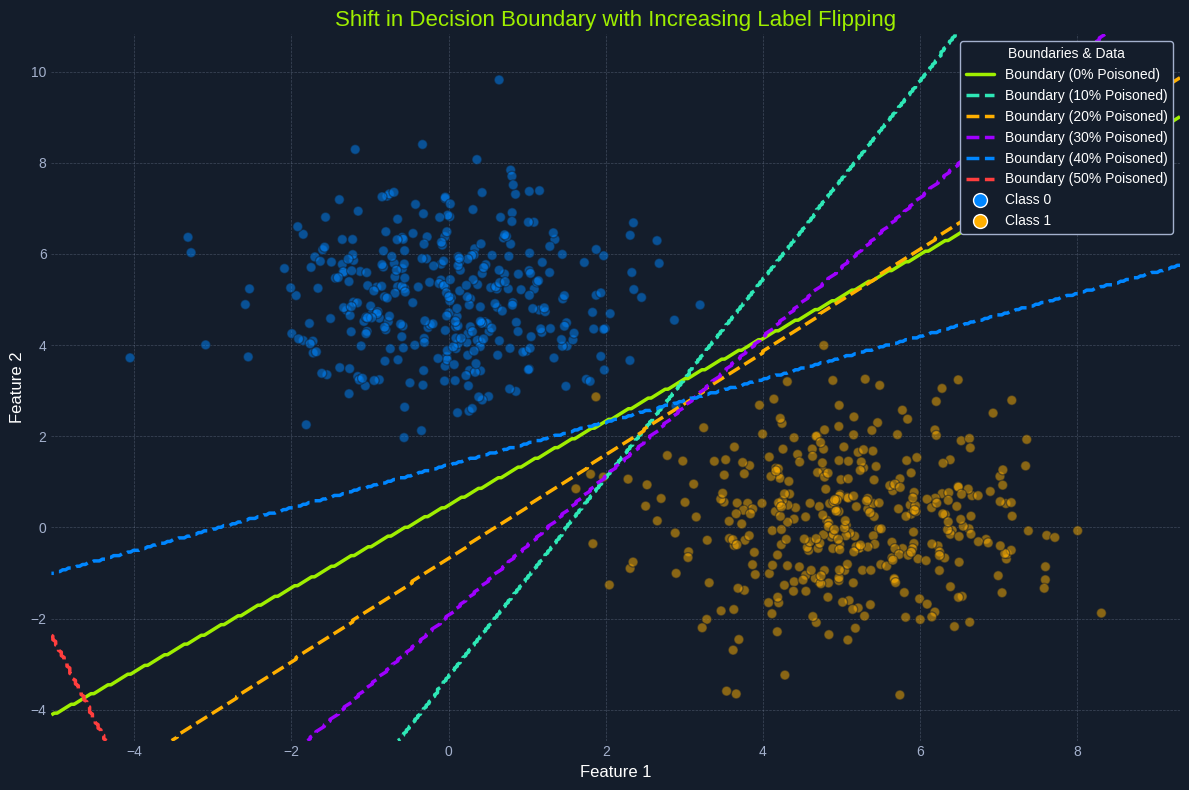

Done — plot saved to label_poisoning_viz.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ── Color palette ──────────────────────────────────────────────────────────────
htb_green      = "#9fef00"
node_black     = "#141d2b"
hacker_grey    = "#a4b1cd"
white          = "#ffffff"
azure          = "#0086ff"
nugget_yellow  = "#ffaf00"
malware_red    = "#ff3e3e"
vivid_purple   = "#9f00ff"
aquamarine     = "#2ee7b6"

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({
    "figure.facecolor":   node_black,
    "axes.facecolor":     node_black,
    "axes.edgecolor":     hacker_grey,
    "axes.labelcolor":    white,
    "text.color":         white,
    "xtick.color":        hacker_grey,
    "ytick.color":        hacker_grey,
    "grid.color":         hacker_grey,
    "grid.alpha":         0.1,
    "legend.facecolor":   node_black,
    "legend.edgecolor":   hacker_grey,
    "legend.frameon":     True,
    "legend.framealpha":  1.0,
    "legend.labelcolor":  white,
})

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 1337
np.random.seed(SEED)

print("Setup complete. Libraries imported and styles configured.")

# ── Data generation ────────────────────────────────────────────────────────────
n_samples = 1000
centers   = [(0, 5), (5, 0)]

X, y = make_blobs(
    n_samples=n_samples,
    centers=centers,
    n_features=2,
    cluster_std=1.25,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training samples: {len(X_train)}  |  Test samples: {len(X_test)}")

# ── Mesh grid for decision boundaries ─────────────────────────────────────────
margin = 1.0
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - margin, X[:, 0].max() + margin, 400),
    np.linspace(X[:, 1].min() - margin, X[:, 1].max() + margin, 400),
)
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# ── Poisoning experiment ───────────────────────────────────────────────────────
poison_percentages = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]

results                = {"percentage": [], "model": [], "accuracy": []}
decision_boundaries_data = []

for pp in poison_percentages:
    y_poisoned = y_train.copy()

    if pp > 0:
        n_flip    = int(pp * len(y_train))
        flip_idx  = np.random.choice(len(y_train), size=n_flip, replace=False)
        y_poisoned[flip_idx] = 1 - y_poisoned[flip_idx]   # flip 0↔1

    model = LogisticRegression(random_state=SEED, max_iter=1000)
    model.fit(X_train, y_poisoned)

    acc = accuracy_score(y_test, model.predict(X_test))

    results["percentage"].append(pp)
    results["model"].append(model)
    results["accuracy"].append(acc)

    Z = model.predict(mesh_points).reshape(xx.shape)
    decision_boundaries_data.append({"percentage": pp, "Z": Z})

    print(f"  {pp*100:4.0f}% poisoned  →  test accuracy: {acc:.3f}")

# ── Contour style maps ─────────────────────────────────────────────────────────
contour_colors = {
    0.0:  htb_green,
    0.10: aquamarine,
    0.20: nugget_yellow,
    0.30: vivid_purple,
    0.40: azure,
    0.50: malware_red,
}
contour_linestyles = {
    0.0:  "solid",
    0.10: "dashed",
    0.20: "dashed",
    0.30: "dashed",
    0.40: "dashed",
    0.50: "dashed",
}

# ── Plot ─────────────────────────────────────
──────────────────────────────────
plt.figure(figsize=(12, 8))

# Scatter: clean training data
plt.scatter(
    X_train[:, 0], X_train[:, 1],
    c=y_train,
    cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
    edgecolors=node_black,
    s=50, alpha=0.5,
    label="Clean Data Points",
)

# Baseline boundary (0 % poisoned)
baseline_idx   = results["percentage"].index(0.0)
baseline_model = results["model"][baseline_idx]
Z_baseline     = baseline_model.predict(mesh_points).reshape(xx.shape)

plt.contour(
    xx, yy, Z_baseline,
    levels=[0.5],
    colors=[contour_colors[0.0]],
    linestyles=[contour_linestyles[0.0]],
    linewidths=[2.5],
)

# Poisoned boundaries
boundary_indices_to_plot = [0.10, 0.20, 0.30, 0.40, 0.50]
plotted_percentages      = [0.0]

decision_boundaries_data.sort(key=lambda item: item["percentage"])

for data in decision_boundaries_data:
    pp = data["percentage"]
    if pp in boundary_indices_to_plot:
        plt.contour(
            xx, yy, data["Z"],
            levels=[0.5],
            colors=[contour_colors[pp]],
            linestyles=[contour_linestyles[pp]],
            linewidths=[2.5],
        )
        plotted_percentages.append(pp)

# ── Title & axes ───────────────────────────────────────────────────────────────
plt.title(
    "Shift in Decision Boundary with Increasing Label Flipping",
    fontsize=16, color=htb_green,
)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_handles = [
    plt.Line2D(
        [0], [0],
        color=contour_colors[pp], lw=2.5,
        linestyle=contour_linestyles[pp],
        label=f"Boundary ({pp*100:.0f}% Poisoned)",
    )
    for pp in sorted(plotted_percentages)
    if pp in contour_colors
]

data_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="Class 0",
               markersize=10, markerfacecolor=azure,         linestyle="None"),
    plt.Line2D([0], [0], marker="o", color="w", label="Class 1",
               markersize=10, markerfacecolor=nugget_yellow, linestyle="None"),
]

plt.legend(handles=legend_handles + data_handles, title="Boundaries & Data")
plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.tight_layout()
plt.savefig("./label_poisoning.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done — plot saved to label_poisoning_viz.png")